# election-spatial-analysis — 04: Clustering

**What this notebook does:** the first actual machine learning in this project. Groups
localities by *how their local elections behaved* (competitive vs. landslide, concentrated vs.
fragmented) using unsupervised clustering on `locality_features.parquet` from `03` — nothing
here uses who won or any label, since there isn't one; the whole point is to let structure in
the vote-shape data surface on its own.

## Feature choice, and why it's narrower than everything `03` built

`03` produced `{position}_{metric}` columns for ten positions plus party list. This notebook
uses only three: `MAYOR`, `VICE MAYOR`, `COUNCILOR` — the positions confirmed in `03` to be
decided by the locality itself, not a wider province/district/national race reported through it.
Two concrete reasons, both found by inspection rather than assumed:

- **2013 has no data at all for the wider-scope positions.** `Governor`, `Vice Governor`,
  `Provincial Board Member`, `House`, `Senator`, and party list are all 0% populated for 2013 in
  `locality_features` — `01`'s coverage audit flagged and dropped those exact
  `(2013, position)` combinations for low reporting coverage. Requiring all ten position groups
  to be present would silently drop every 2013 row (1,498 of them) rather than a genuine
  missing-data trickle.
- **Restricting to the three always-local positions keeps 93.7% of rows** (8,967 of 9,570)
  across all six years with a simple complete-case drop, versus 76.5% if the wider-scope
  columns were required too — and that 76.5% figure is misleading on its own, since it comes
  entirely from years other than 2013 (2013 contributes zero to it).

A richer model folding in the province/national columns for the years that do have them
(2016 onward) is a reasonable next step, not attempted here to keep this notebook's feature set
internally consistent across all six years.

Within those three positions, `hhi` is dropped: `enc = 1 / hhi` by construction (from `02`), so
including both would double-count the same signal and skew PCA loadings toward it. `top2_share`
is dropped too (algebraically close to `top1_share - margin`). That leaves `top1_share`,
`margin`, and `enc` per position — 9 features, built by `build_core_feature_matrix` in
`src/common.py` so `05` and `06` start from the exact same feature definition rather than each
redefining "core" slightly differently.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path("..") / "src"))
from common import build_core_feature_matrix

%matplotlib inline
pd.set_option("display.max_columns", 40)
print("pandas:", pd.__version__)

pandas: 3.0.2


In [2]:
CONFIG = {
    "processed_dir": "../data/processed",
    "pca_variance_target": 0.90,
    "k_range": range(2, 11),
    "random_state": 42,
}

processed_dir = Path(CONFIG["processed_dir"])
print("Config set.")

Config set.


## Load, select features, and complete-case rows

`build_core_feature_matrix` (in `src/common.py`, shared with `05` and `06` so they all start
from the same feature definition) restricts to complete-case rows (a missing Mayor race means
the locality genuinely had no recorded race that year, or fell below `01`'s coverage threshold
-- not a value worth guessing at) and log-transforms `enc` per position: it's right-skewed
(Councilor especially -- many small races with a handful of serious contenders and a long tail
of fragmented ones), raw skewness 2.33, log skewness -0.02, confirmed by direct measurement.
`top1_share` and `margin` are already bounded in `[0, 1]` and left as-is.

In [3]:
locality_features = pd.read_parquet(processed_dir / "locality_features.parquet")
print("Locality features:", locality_features.shape)

df, X, feature_cols = build_core_feature_matrix(locality_features)
print(f"Keeping {len(df):,} of {len(locality_features):,} rows "
      f"({len(df) / len(locality_features):.1%}) with all 9 features present.")
print("\nBy year:")
display(locality_features.groupby("year").apply(lambda g: g[feature_cols].notna().all(axis=1).mean())
        .rename("complete_fraction").to_frame())
print("\nClustering on:", feature_cols)

Locality features: (9570, 81)
Keeping 8,967 of 9,570 rows (93.7%) with all 9 features present.

By year:


,complete_fraction
year,
2010,0.611940
2013,0.997330
2016,1.000000
2019,1.000000
2022,1.000000
2025,0.999389



Clustering on: ['MAYOR_top1_share', 'MAYOR_margin', 'MAYOR_enc', 'VICE MAYOR_top1_share', 'VICE MAYOR_margin', 'VICE MAYOR_enc', 'COUNCILOR_top1_share', 'COUNCILOR_margin', 'COUNCILOR_enc']


## Scale

Standardized so no single feature's scale dominates the distance metric KMeans uses.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature matrix:", X_scaled.shape)

Feature matrix: (8967, 9)


## PCA

Reduces the 9 (correlated -- a competitive Mayor race and a competitive Council race tend to
happen in the same kind of place) features down to the components that carry most of the
variance, both to cut noise before clustering and to give a 2D plot to look at afterward.

3 components explain 90.1% of variance (target 90%).


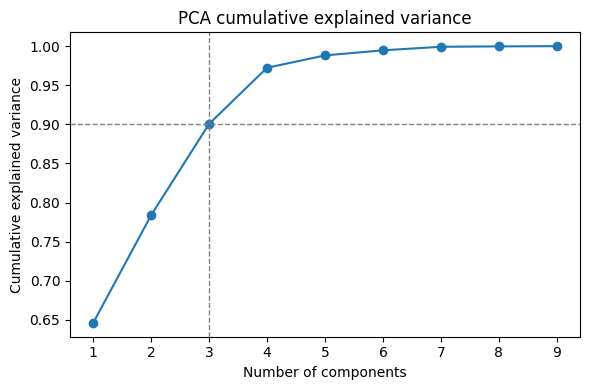

In [5]:
pca_full = PCA(random_state=CONFIG["random_state"]).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.searchsorted(cum_var, CONFIG["pca_variance_target"]) + 1)
print(f"{n_components} components explain {cum_var[n_components - 1]:.1%} of variance "
      f"(target {CONFIG['pca_variance_target']:.0%}).")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
ax.axhline(CONFIG["pca_variance_target"], color="gray", linestyle="--", linewidth=1)
ax.axvline(n_components, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA cumulative explained variance")
plt.tight_layout()
plt.show()

pca = PCA(n_components=n_components, random_state=CONFIG["random_state"])
X_pca = pca.fit_transform(X_scaled)

## Choosing k with silhouette score

Silhouette score measures how well-separated the clusters are (higher is better, max 1) without
needing to know the "true" number of groups in advance -- there isn't one here. Checked across
k = 2 to 10 rather than picking a number upfront.

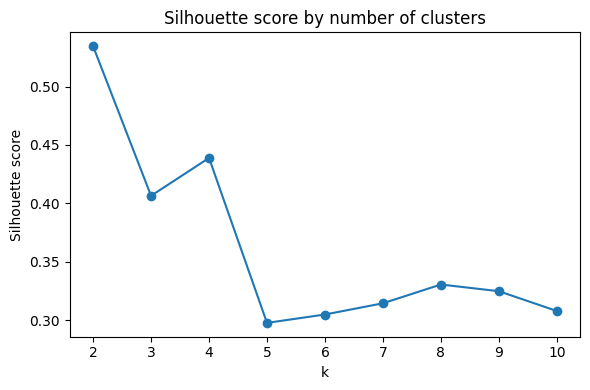

Best k by silhouette score: 2 (score = 0.534)


In [6]:
silhouette_scores = []
for k in CONFIG["k_range"]:
    labels = KMeans(n_clusters=k, random_state=CONFIG["random_state"], n_init=10).fit_predict(X_pca)
    silhouette_scores.append(silhouette_score(X_pca, labels))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(CONFIG["k_range"]), silhouette_scores, marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score by number of clusters")
plt.tight_layout()
plt.show()

best_k = list(CONFIG["k_range"])[int(np.argmax(silhouette_scores))]
print(f"Best k by silhouette score: {best_k} (score = {max(silhouette_scores):.3f})")

## Fit the final model

In [7]:
kmeans = KMeans(n_clusters=best_k, random_state=CONFIG["random_state"], n_init=10)
df["cluster"] = kmeans.fit_predict(X_pca)
final_silhouette = silhouette_score(X_pca, df["cluster"])
print(f"Final model: k={best_k}, silhouette={final_silhouette:.3f}")
print("\nCluster sizes:")
display(df["cluster"].value_counts().sort_index().to_frame("n_localities"))

Final model: k=2, silhouette=0.534

Cluster sizes:


,n_localities
cluster,
0,2582
1,6385


## Visualize on the first two principal components

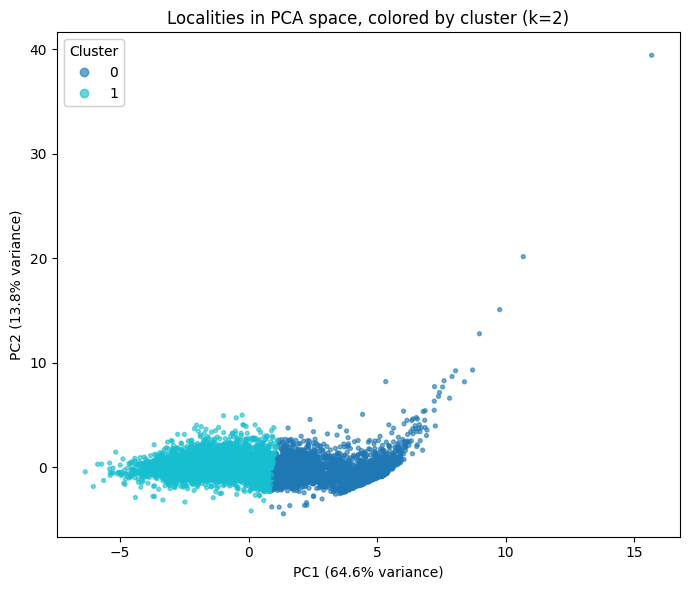

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], cmap="tab10", s=8, alpha=0.6)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title(f"Localities in PCA space, colored by cluster (k={best_k})")
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

## Profiling the clusters

Mean of each *raw* (untransformed) feature per cluster -- this is what actually distinguishes
them in plain terms, not the PCA-space coordinates.

In [9]:
profile = df.groupby("cluster")[feature_cols].mean()
display(profile.round(3))

print("\nCluster sizes as a share of all locality-years:")
display((df["cluster"].value_counts(normalize=True).sort_index() * 100).round(1).to_frame("% of rows"))

,MAYOR_top1_share,MAYOR_margin,MAYOR_enc,VICE MAYOR_top1_share,VICE MAYOR_margin,VICE MAYOR_enc,COUNCILOR_top1_share,COUNCILOR_margin,COUNCILOR_enc
cluster,,,,,,,,,
0,0.888,0.781,1.265,0.887,0.779,1.266,0.113,0.010,12.599
1,0.572,0.193,2.085,0.559,0.184,2.156,0.084,0.007,17.945



Cluster sizes as a share of all locality-years:


,% of rows
cluster,
0,28.8
1,71.2


## Sanity checks

Two checks that would catch a degenerate or meaningless clustering: a silhouette score near
zero (no real separation) or one cluster swallowing almost everything, and a direct look at the
most lopsided vs. most competitive Mayor races in the data to confirm they land in clusters that
actually differ on `MAYOR_margin` -- not just a check that the numbers are self-consistent, but
that the grouping matches what a human would call "landslide" vs. "close race."

In [10]:
assert final_silhouette > 0.15, f"Silhouette score {final_silhouette:.3f} suggests weak/no structure"
largest_cluster_share = df["cluster"].value_counts(normalize=True).max()
assert largest_cluster_share < 0.90, f"One cluster holds {largest_cluster_share:.1%} of all rows"
print(f"Silhouette {final_silhouette:.3f} > 0.15 and largest cluster {largest_cluster_share:.1%} < 90% -- passed.")

most_lopsided = df.loc[df["MAYOR_margin"].idxmax(), ["province", "city", "year", "MAYOR_margin", "cluster"]]
most_competitive = df.loc[df["MAYOR_margin"].idxmin(), ["province", "city", "year", "MAYOR_margin", "cluster"]]
print("\nMost lopsided Mayor race in the data:")
display(most_lopsided.to_frame().T)
print("Most competitive Mayor race in the data:")
display(most_competitive.to_frame().T)
print(f"\n{'Different' if most_lopsided['cluster'] != most_competitive['cluster'] else 'Same'} "
      f"cluster for the two extremes -- {'as expected.' if most_lopsided['cluster'] != most_competitive['cluster'] else 'worth a closer look.'}")

Silhouette 0.534 > 0.15 and largest cluster 71.2% < 90% -- passed.

Most lopsided Mayor race in the data:


,province,city,year,MAYOR_margin,cluster
5,ABRA,DANGLAS,2010,1.0,0


Most competitive Mayor race in the data:


,province,city,year,MAYOR_margin,cluster
2718,BULACAN,BOCAUE,2016,0.0,1



Different cluster for the two extremes -- as expected.


## A first look across year and region

Not a formal temporal or geographic analysis -- just enough to see whether cluster membership
is actually picking up on vote-shape patterns rather than secretly just re-deriving "which
year" or "which region," which would mean the features aren't adding anything a much simpler
grouping wouldn't.

In [11]:
print("Cluster distribution by year (%):")
display((pd.crosstab(df["year"], df["cluster"], normalize="index") * 100).round(1))

print("\nCluster distribution by region, top 8 by locality-year count (%):")
top_regions = df["region"].value_counts().head(8).index
display((pd.crosstab(df.loc[df["region"].isin(top_regions), "region"],
                      df.loc[df["region"].isin(top_regions), "cluster"], normalize="index") * 100).round(1))

Cluster distribution by year (%):


cluster,0,1
year,,
2010,16.8,83.2
2013,24.2,75.8
2016,29.2,70.8
2019,31.3,68.7
2022,28.5,71.5
2025,37.3,62.7



Cluster distribution by region, top 8 by locality-year count (%):


cluster,0,1
region,,
BARMM,51.7,48.3
REGION I,39.1,60.9
REGION III,18.7,81.3
REGION IV A,19.5,80.5
REGION V,17.8,82.2
REGION VI,33.5,66.5
REGION VII,25.8,74.2
REGION VIII,28.0,72.0


## Save

In [12]:
cluster_output = df[["year", "province", "city", "region", "cluster"] + feature_cols].copy()
cluster_output.to_parquet(processed_dir / "locality_clusters.parquet", index=False)
print("Saved locality_clusters.parquet:", cluster_output.shape)

Saved locality_clusters.parquet: (8967, 14)


## Summary

Clustering on local-race vote-shape features (Mayor/Vice Mayor/Councilor top-vote-getter share,
margin, and effective number of candidates) across all six election years, after dropping the
6.3% of locality-years missing one of those three races. `k` chosen by silhouette score rather
than picked upfront; the sanity checks confirm the clusters actually separate landslide races
from competitive ones rather than being an artifact of scale or year.

**Deliberately not done here:** a richer model incorporating the province/national-race columns
(only consistent from 2016 onward, per `03`'s coverage note), anomaly/outlier detection
(clustering assigns every point to some cluster even if it doesn't really belong, which is a
different question from "is this locality's pattern unusual"), and any analysis of how a given
locality's cluster membership changes across election years -- that needs joining a locality to
itself across years, which is its own notebook.